In [1]:
!pip install numpy
!pip install matplotlib
!pip install opencv-python


[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

Image shape: (500, 325)


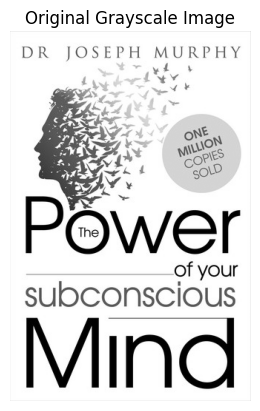

In [3]:
# Load image in grayscale
img1 = cv2.imread("pom1.png", cv2.IMREAD_GRAYSCALE)

# Check if image loaded properly
if img1 is None:
    print("Image not found. Check the file path.")
else:
    print("Image shape:", img1.shape)
    # Display image only if it was loaded successfully
    plt.imshow(img1, cmap="gray")
    plt.title("Original Grayscale Image")
    plt.axis("off")
    plt.show()

Image shape: (410, 339)


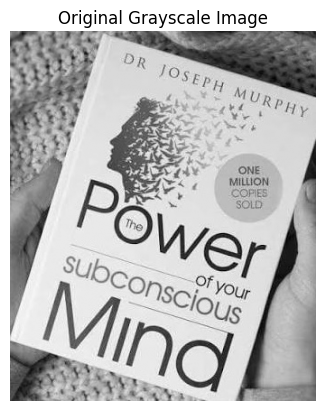

In [4]:
# Load image in grayscale
img2 = cv2.imread("pom2.jpeg", cv2.IMREAD_GRAYSCALE)

# Check if image loaded properly
if img2 is None:
    print("Image not found. Check the file path.")
else:
    print("Image shape:", img2.shape)
    # Display image only if it was loaded successfully
    plt.imshow(img2, cmap="gray")
    plt.title("Original Grayscale Image")
    plt.axis("off")
    plt.show()

In [5]:
# rows, cols = img2.shape
# M = cv2.getRotationMatrix2D(((cols-1)/2.0, (rows-1)/2.0), 45, 1)
# img2 = cv2.warpAffine(img2, M, (cols, rows))

# plt.figure(figsize=(6, 6))
# plt.imshow(img2, cmap="gray")
# plt.title("Rotated Image (45 degrees)")
# plt.axis("off")
# plt.show()

In [6]:
# h, w = img2.shape

# # crop center region manually
# crop_percent = 0.18   # increase if black corners remain

# y1 = int(h * crop_percent)
# y2 = int(h * (1 - crop_percent))
# x1 = int(w * crop_percent)
# x2 = int(w * (1 - crop_percent))

# img2 = img2[y1:y2, x1:x2]

# plt.imshow(img2, cmap="gray")
# plt.axis("off")
# plt.show()

In [7]:
def get_integral_img(img):
    integral_img = np.zeros_like(img, dtype = float)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            integral_img[i,j] = np.sum(img[:i+1, :j+1])

    integral_img = np.pad(integral_img, 1)
    return integral_img[:-1, :-1]

In [8]:
integral_img1 = get_integral_img(img1)

In [9]:
integral_img1

array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 2.2800000e+02, 4.6400000e+02, ..., 7.6218000e+04,
        7.6455000e+04, 7.6676000e+04],
       [0.0000000e+00, 4.7400000e+02, 9.6400000e+02, ..., 1.5825100e+05,
        1.5874200e+05, 1.5920000e+05],
       ...,
       [0.0000000e+00, 1.2249300e+05, 2.4897100e+05, ..., 3.4377216e+07,
        3.4503696e+07, 3.4621707e+07],
       [0.0000000e+00, 1.2274100e+05, 2.4947400e+05, ..., 3.4459574e+07,
        3.4586309e+07, 3.4704559e+07],
       [0.0000000e+00, 1.2297300e+05, 2.4994800e+05, ..., 3.4537406e+07,
        3.4664383e+07, 3.4782858e+07]], shape=(501, 326))

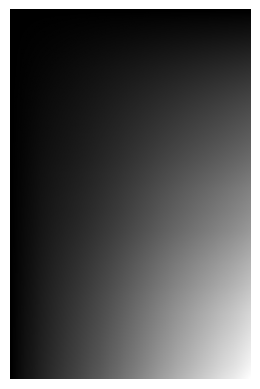

In [10]:
plt.imshow(integral_img1, cmap="gray")
plt.axis("off")
plt.show()

In [11]:
integral_img2 = get_integral_img(img2)

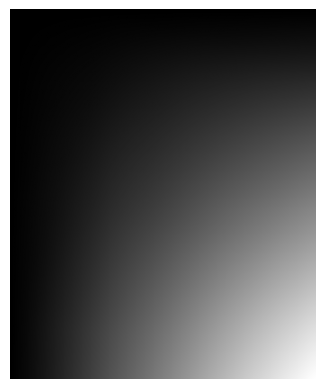

In [12]:
plt.imshow(integral_img2, cmap="gray")
plt.axis("off")
plt.show()

In [13]:
def get_rect_sum(ii, x0, y0, x1, y1):
    return ii[x1, y1] - ii[x0, y1] - ii[x1, y0] + ii[x0, y0]

In [14]:
def dxx(ii, filter_size, x, y):
    half = filter_size // 2
    N = filter_size // 3

    x0 = x - half
    x1 = x0 + N
    x2 = x1 + N
    x3 = x2 + N

    y0 = y - half
    y1 = y + half + 1

    rect_left = get_rect_sum(ii, x0, y0, x1, y1)
    rect_mid = get_rect_sum(ii, x1, y0, x2, y1)
    rect_right = get_rect_sum(ii, x2, y0, x3, y1)

    return rect_left + rect_right - 2 * rect_mid

In [15]:
def dyy(ii, filter_size, x, y):
    half = filter_size // 2
    N = filter_size // 3

    y0 = y - half
    y1 = y0 + N
    y2 = y1 + N
    y3 = y2 + N

    x0 = x - half
    x1 = x + half + 1

    rect_top = get_rect_sum(ii, x0, y0, x1, y1)
    rect_mid = get_rect_sum(ii, x0, y1, x1, y2)
    rect_bottom = get_rect_sum(ii, x0, y2, x1, y3)

    return rect_top + rect_bottom - 2 * rect_mid

In [16]:
def dxy(ii, filter_size, x, y):
    half = filter_size // 2
    N = filter_size // 3

    # top-left positive box
    rect_top_left = get_rect_sum(
        ii,
        x - half, y - half,
        x - half + N, y - half + N
    )

    # top-right negative box
    rect_top_right = get_rect_sum(
        ii,
        x + half - N + 1, y - half,
        x + half + 1,     y - half + N
    )

    # bottom-left negative box
    rect_bottom_left = get_rect_sum(
        ii,
        x - half,     y + half - N + 1,
        x - half + N, y + half + 1
    )

    # bottom-right positive box
    rect_bottom_right = get_rect_sum(
        ii,
        x + half - N + 1, y + half - N + 1,
        x + half + 1,     y + half + 1
    )

    return rect_top_left + rect_bottom_right - rect_top_right - rect_bottom_left

In [17]:
def make_surf_octaves(num_octaves=4, num_layers=4):
    octaves = []

    start = 9
    step = 6

    for o in range(num_octaves):
        octave_filters = []

        for l in range(num_layers):
            size = start + l * step
            octave_filters.append(size)

        octaves.append(octave_filters)

        start = octave_filters[1]
        step *= 2

    return octaves



In [18]:
# filters

In [19]:
def compute_filter_maps(img, ii, filter_size):
    H, W = img.shape

    Dxx_map = np.zeros((H, W), dtype=np.float32)
    Dyy_map = np.zeros((H, W), dtype=np.float32)
    Dxy_map = np.zeros((H, W), dtype=np.float32)
    response_map = np.zeros((H, W), dtype=np.float32)

    half = filter_size // 2

    for x in range(half, H - half):
        for y in range(half, W - half):

            Dxx = dxx(ii, filter_size, x, y)
            Dyy = dyy(ii, filter_size, x, y)
            Dxy = dxy(ii, filter_size, x, y)

            detH = Dxx * Dyy - (0.9 * Dxy) ** 2

            Dxx_map[x, y] = Dxx
            Dyy_map[x, y] = Dyy
            Dxy_map[x, y] = Dxy
            response_map[x, y] = detH / (filter_size ** 4)

    return Dxx_map, Dyy_map, Dxy_map, response_map

In [20]:
##FOR IMAGE 1

In [21]:
# surf_maps = {}

# for octave_idx, filter_sizes in enumerate(filters):
#     surf_maps[octave_idx] = {}

#     for filter_size in filter_sizes:
#         Dxx_map, Dyy_map, Dxy_map, response_map = compute_filter_maps(
#             img1, integral_img1, filter_size
#         )

#         surf_maps[octave_idx][filter_size] = {
#             "Dxx": Dxx_map,
#             "Dyy": Dyy_map,
#             "Dxy": Dxy_map,
#             "response": response_map
#         }

In [22]:
# surf_maps

In [23]:
# plt.figure(figsize=(6, 6))
# plt.imshow(surf_maps[0][9]['Dyy'], cmap="gray")
# plt.title("Rotated Image (45 degrees)")
# plt.axis("off")
# plt.show()

In [24]:
# candidate_kp = []
# # strong_kp = {}

# threshold = 0.02

In [25]:
def build_surf_maps(img, integral_img, filters):
    surf_maps = {}

    for octave_idx, filter_sizes in enumerate(filters):
        surf_maps[octave_idx] = {}

        for filter_size in filter_sizes:
            Dxx_map, Dyy_map, Dxy_map, response_map = compute_filter_maps(
                img, integral_img, filter_size
            )

            surf_maps[octave_idx][filter_size] = {
                "Dxx": Dxx_map,
                "Dyy": Dyy_map,
                "Dxy": Dxy_map,
                "response": response_map
            }

    return surf_maps

In [26]:
def detect_surf_keypoints(surf_maps, filters, threshold, num_octaves, max_keypoints=None):
    candidate_kp = []

    for octave in range(num_octaves):
        for filter_layer in range(1, len(filters[octave]) - 1):

            prev_filter = filters[octave][filter_layer - 1]
            curr_filter = filters[octave][filter_layer]
            next_filter = filters[octave][filter_layer + 1]

            prev_layer = surf_maps[octave][prev_filter]["response"]
            curr_layer = surf_maps[octave][curr_filter]["response"]
            next_layer = surf_maps[octave][next_filter]["response"]

            response_stack = np.stack(
                [prev_layer, curr_layer, next_layer],
                axis=0
            )

            H, W = curr_layer.shape

            # skip borders where 3x3 patch or filter may go out
            margin = max(prev_filter, curr_filter, next_filter) // 2

            for y in range(margin, H - margin):
                for x in range(margin, W - margin):

                    center = response_stack[1, y, x]

                    if center < threshold:
                        continue

                    patch = response_stack[:, y - 1:y + 2, x - 1:x + 2]
                    values = patch.reshape(-1)

                    # remove center value from 3x3x3 patch
                    neighbors = np.delete(values, 13)

                    if center > np.max(neighbors):
                        candidate_kp.append({
                            "octave": octave,
                            "scale_idx": filter_layer,
                            "filter_size": curr_filter,
                            "y": y,
                            "x": x,
                            "response": float(center)
                        })

    # sort strongest keypoints first
    candidate_kp = sorted(
        candidate_kp,
        key=lambda kp: kp["response"],
        reverse=True
    )

    if max_keypoints is not None:
        candidate_kp = candidate_kp[:max_keypoints]

    return candidate_kp

In [27]:
# step_size = 6
# for octave in range(num_octaves):
#     for filter_layer in range(1, len(filters[octave])-1):
#           prev_filter = filters[octave][filter_layer - 1]
#           curr_filter = filters[octave][filter_layer]
#           next_filter = filters[octave][filter_layer + 1]
#           # print(filter_layer)
#           prev_layer = surf_maps[octave][prev_filter]['response']
#           curr_layer = surf_maps[octave][curr_filter]['response']
#           next_layer = surf_maps[octave][next_filter]['response']
#           # print(curr_layer)
#           response_stack = np.stack([prev_layer, curr_layer, next_layer], axis=0)
#           H, W = curr_layer.shape
#           for i in range(1, H - 1):
#               for j in range(1, W - 1):
#                   patch = response_stack[:, i - 1:i + 2, j - 1:j + 2]
#                   center = patch[1, 1, 1]
#                   values = patch.reshape(-1)
#                   neighbors = np.delete(values, 13)

#                   if center < threshold:
#                       continue
        
#                   if center > np.max(neighbors):
#                         candidate_kp.append({
#                         "octave": octave,
#                         "scale_idx": filter_layer,
#                         "filter_size": curr_filter,
#                         "y": i,
#                         "x": j,
#                         "response": float(center)
#                     })
                      
#           # print(response_stack)

In [28]:
# candidate_kp1 = 

In [29]:
# len(candidate_kp)

In [30]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 6))
# plt.imshow(img1, cmap="gray")

# xs = [kp["x"] for kp in candidate_kp]
# ys = [kp["y"] for kp in candidate_kp]

# plt.scatter(xs, ys, s=10, facecolors="none", edgecolors="r")
# plt.title(f"SURF candidate keypoints: {len(candidate_kp)}")
# plt.axis("off")
# plt.show()

In [31]:
def haar_x(ii, x, y, size):
    half = size // 2

    x0 = x - half
    x1 = x
    x2 = x + half

    y0 = y - half
    y1 = y + half

    left_sum = get_rect_sum(ii, y0, x0, y1, x1)
    right_sum = get_rect_sum(ii, y0, x1, y1, x2)

    return right_sum - left_sum


def haar_y(ii, x, y, size):
    half = size // 2

    x0 = x - half
    x1 = x + half

    y0 = y - half
    y1 = y
    y2 = y + half

    top_sum = get_rect_sum(ii, y0, x0, y1, x1)
    bottom_sum = get_rect_sum(ii, y1, x0, y2, x1)

    return bottom_sum - top_sum

In [32]:
# def haar_x(ii, x, y, size):
#     half = size // 2
#     x0 = x - half
#     x1 = x + half 
#     y0 = y - half
#     y1 = y + half

#     left_sum = get_rect_sum(ii, x0, y0, x, y1)
#     right_sum = get_rect_sum(ii, x, y0, x1, y1)

#     return right_sum - left_sum

In [33]:
# def haar_y(ii, x, y, size):
#     half = size // 2
#     x0 = x - half
#     x1 = x + half 
#     y0 = y - half
#     y1 = y + half

#     top_sum = get_rect_sum(ii, x0, y0, x1, y)
#     bottom_sum = get_rect_sum(ii, x0, y, x1, y1)

#     return bottom_sum - top_sum

In [34]:
def get_orientation(ii, kp, img_shape):
    H, W = img_shape

    x = kp["x"]
    y = kp["y"]

    filter_size = kp["filter_size"]
    haar_size = max(2, filter_size // 3)

    if haar_size % 2 == 1:
        haar_size += 1

    radius = 6 * haar_size

    angles = []
    dxs = []
    dys = []

    for i in range(y - radius, y + radius + 1):
        for j in range(x - radius, x + radius + 1):

            # circular region around keypoint
            if (j - x) ** 2 + (i - y) ** 2 > radius ** 2:
                continue

            # border check
            half = haar_size // 2

            if i - half < 0 or i + half >= H:
                continue
            if j - half < 0 or j + half >= W:
                continue

            dx = haar_x(ii, j, i, haar_size)
            dy = haar_y(ii, j, i, haar_size)

            angle = np.degrees(np.arctan2(dy, dx)) % 360

            angles.append(angle)
            dxs.append(dx)
            dys.append(dy)

    if len(angles) == 0:
        return 0.0

    window_size = 60
    step = 10

    windows = []
    sum_dx = []
    sum_dy = []

    for start_angle in range(0, 360, step):
        end_angle = start_angle + window_size

        if end_angle <= 360:
            indexes = [
                i for i in range(len(angles))
                if start_angle <= angles[i] < end_angle
            ]
        else:
            wrapped_end = end_angle - 360
            indexes = [
                i for i in range(len(angles))
                if angles[i] >= start_angle or angles[i] < wrapped_end
            ]

        selected_dxs = [dxs[i] for i in indexes]
        selected_dys = [dys[i] for i in indexes]

        curr_sum_dx = sum(selected_dxs)
        curr_sum_dy = sum(selected_dys)

        window_strength = np.sqrt(curr_sum_dx ** 2 + curr_sum_dy ** 2)

        windows.append(window_strength)
        sum_dx.append(curr_sum_dx)
        sum_dy.append(curr_sum_dy)

    best_idx = np.argmax(windows)

    best_dx = sum_dx[best_idx]
    best_dy = sum_dy[best_idx]

    best_angle = np.degrees(np.arctan2(best_dy, best_dx)) % 360

    return best_angle

In [35]:
# candidate_kp

In [36]:
# candidate_kp[0]['angle'] = get_orientation(integral_img1, candidate_kp[0], img1.shape)

In [37]:
# for kp in candidate_kp:
#     kp['angle'] = get_orientation(integral_img1, kp, img1.shape)

In [38]:
def get_feature_descriptor(img, kp, ii, size = 20):
    H, W = img.shape
    scale = kp['filter_size']//3
    half = (size//2) * scale
    x = kp['x']
    y = kp['y']
    cell_size = (size//4) * scale
    descriptor = np.zeros((4, 4, 4), dtype=np.float32)

    # Haar response size for descriptor
    haar_size = max(2, scale)
    if haar_size % 2 == 1:
        haar_size += 1

    haar_half = haar_size // 2

    # keypoint angle is in degrees
    theta = np.radians(kp["angle"])

    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    
    for u in range(- half, half):
        for v in range(- half, half):
            image_x = int(round(x + u * cos_t - v * sin_t))
            image_y = int(round(y + u * sin_t + v * cos_t))

            

            cell_x = int((u + half)//cell_size)
            cell_y = int((v + half)//cell_size)

            if image_x - haar_half < 0 or image_x + haar_half >= W:
                continue
            if image_y - haar_half < 0 or image_y + haar_half >= H:
                continue

            
            if cell_x < 0 or cell_x >= 4 or cell_y < 0 or cell_y >= 4:
                continue

            dx = haar_x(ii, image_x, image_y, haar_size)
            dy = haar_y(ii, image_x, image_y, haar_size)

            rot_x = cos_t * dx + sin_t * dy
            rot_y = -sin_t * dx + cos_t * dy

            descriptor[cell_y, cell_x, 0] += rot_x
            descriptor[cell_y, cell_x, 1] += rot_y
            descriptor[cell_y, cell_x, 2] += abs(rot_x)
            descriptor[cell_y, cell_x, 3] += abs(rot_y)
    descriptor = descriptor.reshape(-1)

    # normalize descriptor
    norm = np.linalg.norm(descriptor)

    if norm > 1e-8:
        descriptor = descriptor / norm

    return descriptor

In [39]:
num_octaves = 4

In [40]:

filters = make_surf_octaves()

for i, octave in enumerate(filters):
    print(f"Octave {i+1}: {octave}")

Octave 1: [9, 15, 21, 27]
Octave 2: [15, 27, 39, 51]
Octave 3: [27, 51, 75, 99]
Octave 4: [51, 99, 147, 195]


In [41]:
surf_maps1 = build_surf_maps(img1, integral_img1, filters)

surf_maps2 = build_surf_maps(img2, integral_img2, filters)

In [42]:
candidate_kp1 = detect_surf_keypoints(
    surf_maps1,
    filters,
    threshold=0.02,
    num_octaves=num_octaves,
    max_keypoints=500
)

candidate_kp2 = detect_surf_keypoints(
    surf_maps2,
    filters,
    threshold=0.02,
    num_octaves=num_octaves,
    max_keypoints=500
)

In [43]:
for kp in candidate_kp1:
    kp['angle'] = get_orientation(integral_img1, kp, img1.shape)

for kp in candidate_kp2:
    kp['angle'] = get_orientation(integral_img2, kp, img2.shape)

In [44]:
descriptors1 = []
valid_kps1 = []

for kp in candidate_kp1:
    kp["angle"] = get_orientation(integral_img1, kp, img1.shape)
    desc = get_feature_descriptor(img1, kp, integral_img1)

    if np.linalg.norm(desc) > 0:
        descriptors1.append(desc)
        valid_kps1.append(kp)

descriptors1 = np.array(descriptors1)

In [45]:
descriptors2 = []
valid_kps2 = []

for kp in candidate_kp2:
    kp["angle"] = get_orientation(integral_img2, kp, img2.shape)
    desc = get_feature_descriptor(img2, kp, integral_img2)

    if np.linalg.norm(desc) > 0:
        descriptors2.append(desc)
        valid_kps2.append(kp)

descriptors2 = np.array(descriptors2)

In [46]:
len(candidate_kp1)

500

In [47]:
len(descriptors2)

500

In [48]:
len(descriptors1)

500

In [49]:
def match_descriptors(descriptors1, descriptors2, ratio_thresh=0.75):
    matches = []

    for i in range(len(descriptors1)):
        desc1 = descriptors1[i]

        # distances from desc1 to every descriptor in image 2
        distances = np.linalg.norm(descriptors2 - desc1, axis=1)

        # get indexes sorted by distance
        sorted_idx = np.argsort(distances)

        best_idx = sorted_idx[0]
        second_best_idx = sorted_idx[1]

        best_dist = distances[best_idx]
        second_best_dist = distances[second_best_idx]

        # Lowe ratio test
        if best_dist < ratio_thresh * second_best_dist:
            matches.append({
                "kp1_idx": i,
                "kp2_idx": best_idx,
                "distance": float(best_dist)
            })

    return matches

In [50]:
matches = match_descriptors(descriptors1, descriptors2, ratio_thresh=0.75)

print("Number of matches:", len(matches))

Number of matches: 67


In [51]:
def show_keypoints(img, kps, max_kps=300, title="Keypoints"):
    kps = sorted(kps, key=lambda kp: kp["response"], reverse=True)
    kps = kps[:max_kps]

    xs = [kp["x"] for kp in kps]
    ys = [kp["y"] for kp in kps]

    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap="gray")
    plt.scatter(xs, ys, s=15, facecolors="none", edgecolors="r")
    plt.title(title)
    plt.axis("off")
    plt.show()

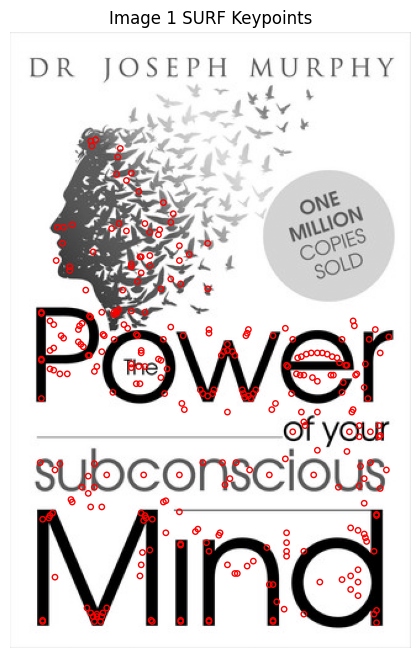

In [52]:
show_keypoints(img1, valid_kps1, title="Image 1 SURF Keypoints")


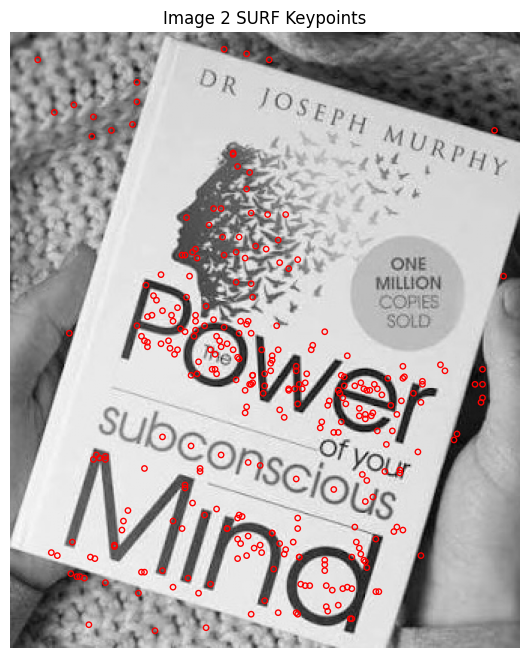

In [53]:
show_keypoints(img2, valid_kps2, title="Image 2 SURF Keypoints")

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def show_matches(img1, img2, kps1, kps2, matches, max_matches=50):
    # sort strongest matches first if distance exists
    matches = sorted(matches, key=lambda m: m["distance"])
    matches = matches[:max_matches]

    H1, W1 = img1.shape[:2]
    H2, W2 = img2.shape[:2]

    H = max(H1, H2)
    W = W1 + W2

    canvas = np.zeros((H, W), dtype=img1.dtype)
    canvas[:H1, :W1] = img1
    canvas[:H2, W1:W1 + W2] = img2

    plt.figure(figsize=(14, 7))
    plt.imshow(canvas, cmap="gray")

    for m in matches:
        kp1 = kps1[m["kp1_idx"]]
        kp2 = kps2[m["kp2_idx"]]

        x1, y1 = kp1["x"], kp1["y"]
        x2, y2 = kp2["x"] + W1, kp2["y"]

        plt.plot([x1, x2], [y1, y2], linewidth=1)
        plt.scatter([x1, x2], [y1, y2], s=12)

    plt.axis("off")
    plt.title(f"Top {len(matches)} SURF Matches")
    plt.show()

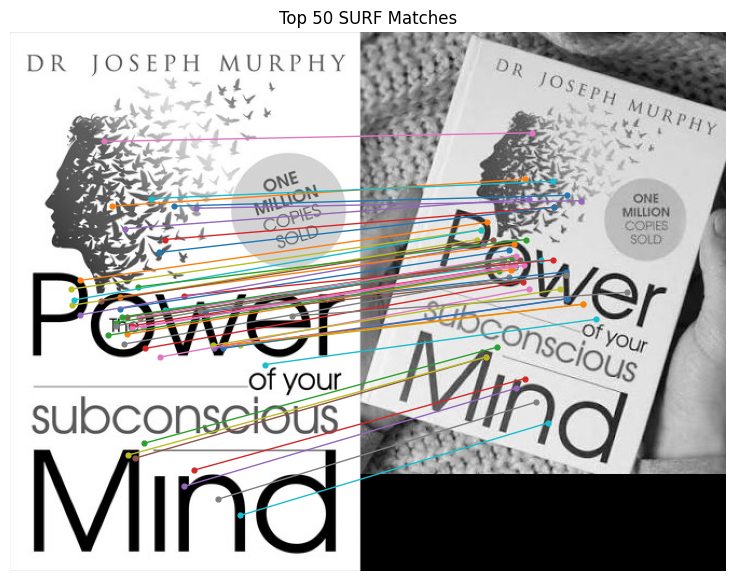

In [55]:
show_matches(img1, img2, valid_kps1, valid_kps2, matches, max_matches=50)